In [2]:
import os
import scipy.io as sio

# Define the data directory
data_dir = '/Users/Erfan/Desktop/CrossSpecies/Datasets/V1V4MonkeyRoelfsema/Raw'

# List all the file names in the data directory
file_names = ['NSP1_array1_LFP.mat', 'NSP1_array2_LFP.mat', 'NSP2_array3_LFP.mat', 'NSP2_array4_LFP.mat', 
              'NSP3_array5_LFP.mat', 'NSP3_array6_LFP.mat', 'NSP4_array7_LFP.mat', 'NSP4_array8_LFP.mat', 
              'NSP5_array9_LFP.mat', 'NSP5_array10_LFP.mat', 'NSP6_array11_LFP.mat', 'NSP6_array12_LFP.mat', 
              'NSP7_array13_LFP.mat', 'NSP7_array14_LFP.mat', 'NSP8_array15_LFP.mat', 'NSP8_array16_LFP.mat']

# Load data from the specified directory
data = []
for file_name in file_names:
    full_path = os.path.join(data_dir, file_name)
    data.append(sio.loadmat(full_path))

In [3]:
import numpy as np
import scipy.io as sio
import scipy.signal as signal
import pywt
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from matplotlib import animation


Fs = 500  # Sampling frequency (Hz)

# Concatenate Arrays
LFP, Loc_X, Loc_Y, Elec_ID, Array_ID = [], [], [], [], []

for d in data:
    LFP.append(d['lfp'])
    Loc_X.append(d['schematic_X_position'])
    Loc_Y.append(d['schematic_Y_position'])
    Elec_ID.append(d['Electrode_ID'])
    Array_ID.append(d['Array_ID'])

LFP = np.concatenate(LFP, axis=1)
Loc_X = np.concatenate(Loc_X)
Loc_Y = np.concatenate(Loc_Y)
Elec_ID = np.concatenate(Elec_ID)
Array_ID = np.concatenate(Array_ID)

Time = np.arange(LFP.shape[0]) / Fs

V4_chan = np.where((Array_ID == 2) | (Array_ID == 3))[0]
V1_chan = np.where((Array_ID != 2) & (Array_ID != 3))[0]

# LFP Preprocessing
time_window = np.arange(10000)
power = []

for chan in range(LFP.shape[1]):
    print(f'Processing channel {chan + 1}')
    filtered_LFP = signal.filtfilt(*signal.iirnotch(60, 30, Fs), LFP[time_window, chan])
    cfs, freqs = pywt.cwt(filtered_LFP, scales=np.arange(1, 129), wavelet='cmor', sampling_period=1/Fs)
    power.append(np.mean(np.abs(cfs)**2, axis=1))

power = np.array(power).T


Processing channel 1


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should takethe form cmorB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: cmor1.5-1.0).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing channel 2


KeyboardInterrupt: 

In [5]:

# Plot Power Spectrum for V4
plt.figure(figsize=(8, 4))
avg_power = np.mean(power[:, V4_chan], axis=1)

for chan in V4_chan[::10]:
    plt.plot(np.log2(freqs), np.log(power[:, chan]), color=[0.5, 0.5, 0.5, 0.2], linewidth=1)

plt.plot(np.log2(freqs), np.log(avg_power), color=[0.5, 0, 0], linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('V4 LFP Power Spectrum')
plt.xticks(np.log2([1, 2, 4, 8, 16, 32, 64, 128]), [1, 2, 4, 8, 16, 32, 64, 128])
plt.grid(True)
plt.show()

# Plot Power Spectrum for V1
plt.figure(figsize=(8, 4))
avg_power = np.mean(power[:, V1_chan], axis=1)

for chan in V1_chan[::10]:
    plt.plot(np.log2(freqs), np.log(power[:, chan]), color=[0.5, 0.5, 0.5, 0.2], linewidth=1)

plt.plot(np.log2(freqs), np.log(avg_power), color=[0.5, 0, 0], linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('V1 LFP Power Spectrum')
plt.xticks(np.log2([1, 2, 4, 8, 16, 32, 64, 128]), [1, 2, 4, 8, 16, 32, 64, 128])
plt.grid(True)
plt.show()

TypeError: list indices must be integers or slices, not tuple

<Figure size 800x400 with 0 Axes>

Extracting phase for channel 1
Extracting phase for channel 2
Extracting phase for channel 3
Extracting phase for channel 4
Extracting phase for channel 5
Extracting phase for channel 6
Extracting phase for channel 7
Extracting phase for channel 8
Extracting phase for channel 9
Extracting phase for channel 10
Extracting phase for channel 11
Extracting phase for channel 12
Extracting phase for channel 13
Extracting phase for channel 14
Extracting phase for channel 15
Extracting phase for channel 16
Extracting phase for channel 17
Extracting phase for channel 18
Extracting phase for channel 19
Extracting phase for channel 20
Extracting phase for channel 21
Extracting phase for channel 22
Extracting phase for channel 23
Extracting phase for channel 24
Extracting phase for channel 25
Extracting phase for channel 26
Extracting phase for channel 27
Extracting phase for channel 28
Extracting phase for channel 29
Extracting phase for channel 30
Extracting phase for channel 31
Extracting phase 

MovieWriter imagemagick unavailable; using Pillow instead.


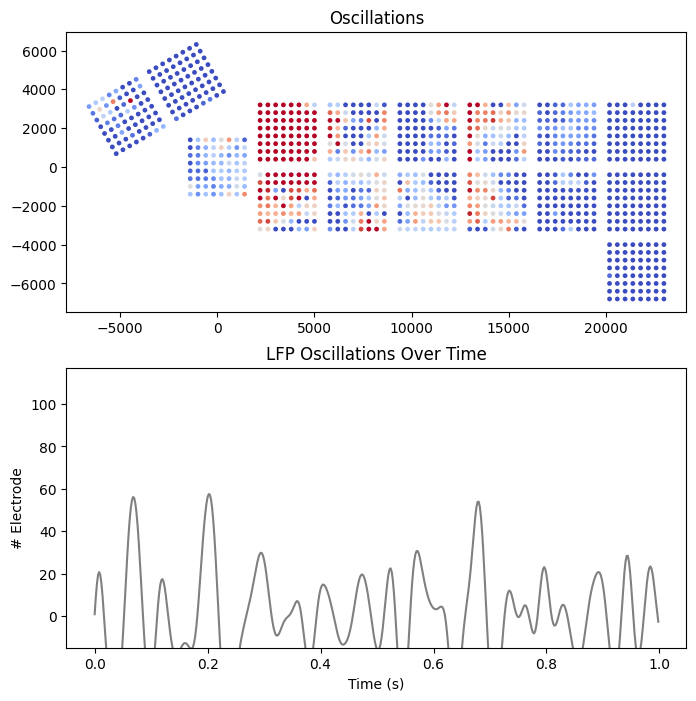

In [37]:

# Phase Extraction
freq_range = [8, 32]
ValidChannels = np.arange(LFP.shape[1])
Phase = np.zeros_like(LFP)
LFP_Oscil = np.zeros_like(LFP)

for channel in ValidChannels:
    print(f'Extracting phase for channel {channel + 1}')
    b, a = signal.butter(2, np.array(freq_range) / (Fs / 2), btype='bandpass')
    LFP_Oscil[:, channel] = signal.filtfilt(b, a, LFP[:, channel])
    Phase[:, channel] = np.mod(np.angle(hilbert(LFP_Oscil[:, channel])) + 2 * np.pi, 2 * np.pi)

# Visualization of Oscillations
step_num = 500
filename = 'LFP_oscillations.gif'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
sc = ax1.scatter(Loc_X, Loc_Y, c=LFP_Oscil[0, :], s=20, cmap='coolwarm', edgecolor='w')
ax1.axis('equal')
ax1.set_title('Oscillations')

lines = []
for chan in range(2, 40, 40):
    line, = ax2.plot(Time[:step_num], 0.05 * np.max(LFP_Oscil) * chan + LFP_Oscil[:step_num, chan], color=[0.5, 0.5, 0.5])
    lines.append(line)

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('# Electrode')
ax2.set_title('LFP Oscillations Over Time')

def update(frame):
    sc.set_array(LFP_Oscil[frame, :])
    for i, line in enumerate(lines):
        line.set_ydata(0.05 * np.max(LFP_Oscil) * i + LFP_Oscil[:step_num, i])
    return sc, *lines

anim = animation.FuncAnimation(fig, update, frames=step_num, blit=True)
anim.save(filename, writer='imagemagick', fps=20)
plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/quiver.py:645: RuntimeWarning: divide by zero encountered in double_scalars
  length = a * (widthu_per_lenu / (self.scale * self.width))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/quiver.py:645: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


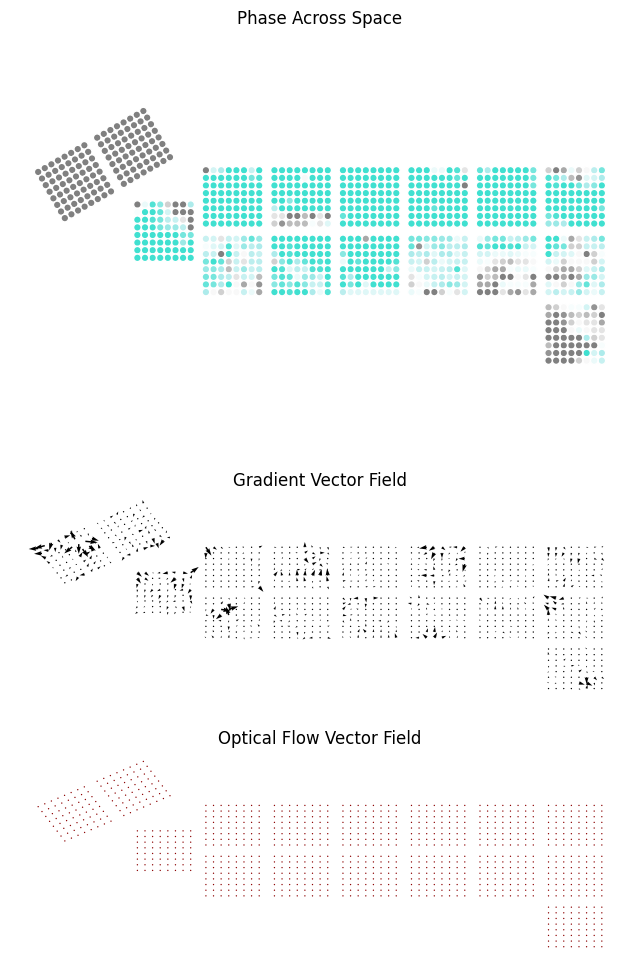

In [43]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import cKDTree  # Efficient nearest-neighbor search

# Flatten Loc_X and Loc_Y
Loc_X_flat = Loc_X.flatten()
Loc_Y_flat = Loc_Y.flatten()

# Ensure Loc_X and Loc_Y have the correct shape matching num_channels
num_frames = 200#LFP_Oscil.shape[0]  # Number of time points
num_channels = LFP_Oscil.shape[1]  # Number of electrodes
assert len(Loc_X_flat) == num_channels, "Loc_X length must match number of electrodes in LFP_Oscil"
assert len(Loc_Y_flat) == num_channels, "Loc_Y length must match number of electrodes in LFP_Oscil"

# Create a KDTree for finding nearest neighbors (for gradient calculation)
coordinates = np.vstack([Loc_X_flat, Loc_Y_flat]).T
tree = cKDTree(coordinates)

# Create the figure for animation with 3 subplots (1 for visualization, 2 for vector fields)
fig, axs = plt.subplots(3, 1, figsize=(8, 12), gridspec_kw={'height_ratios': [2, 1, 1]})

# Create a custom colormap
colors = [(0.5, 0.5, 0.5), (1, 1, 1),	(179/255,236/255,236/255), (64/255, 224/255, 208/255)]  # Teal to gray
n_bins = 20  # Discretizes the interpolation into bins
cmap_name = 'custom_teal_gray'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Create a scatter plot for oscillations over spatial locations
sc = axs[0].scatter(Loc_X_flat, Loc_Y_flat, c=LFP_Oscil[0, :], s=30, cmap=cm, edgecolor='w')
axs[0].axis('equal')
axs[0].set_title('Phase Across Space')

# Initialize the quiver plots with zeros to avoid the size mismatch error
initial_UV = np.zeros_like(Loc_X_flat)
quiver_grad = axs[1].quiver(Loc_X_flat, Loc_Y_flat, initial_UV, initial_UV, color='black')
quiver_flow = axs[2].quiver(Loc_X_flat, Loc_Y_flat, initial_UV, initial_UV, color='darkred')

def calculate_gradient(LFP_Oscil, frame):
    """Calculate the spatial gradients (grad_x, grad_y) using nearest neighbors."""
    grad_x = np.zeros(num_channels)
    grad_y = np.zeros(num_channels)
    
    current_frame = LFP_Oscil[frame, :]
    
    # For each electrode, find the nearest neighbors and calculate the gradient
    for i in range(num_channels):
        # Ensure correct query of nearest neighbors
        distances, indices = tree.query([Loc_X_flat[i], Loc_Y_flat[i]], k=4)  # Find nearest neighbors (excluding itself)
        neighbors = indices[1:]  # Ignore the first result (itself)
        
        # Calculate differences in X and Y coordinates
        dx = Loc_X_flat[neighbors] - Loc_X_flat[i]
        dy = Loc_Y_flat[neighbors] - Loc_Y_flat[i]
        dV = current_frame[neighbors] - current_frame[i]
        
        # Estimate gradient
        grad_x[i] = np.sum(dV * dx / (dx**2 + dy**2))
        grad_y[i] = np.sum(dV * dy / (dx**2 + dy**2))
    
    return grad_x, grad_y

def calculate_optical_flow(LFP_Oscil, frame):
    """Calculate optical flow between two consecutive frames."""
    if frame < num_frames - 1:
        frame1 = LFP_Oscil[frame, :].astype(np.float32)
        frame2 = LFP_Oscil[frame + 1, :].astype(np.float32)
        # Using cv2's optical flow on the original data directly won't work with scattered data,
        # so we treat each pair of consecutive frames as a signal and calculate flow heuristically
        flow_x = frame2 - frame1
        flow_y = flow_x.copy()  # Just simulating flow in X and Y
        return flow_x, flow_y
    else:
        return np.zeros(num_channels), np.zeros(num_channels)


# Initialize the quiver plots with scaled vectors
scale_factor = 10  # Adjust this scale factor to reduce vector length

quiver_grad = axs[1].quiver(Loc_X_flat, Loc_Y_flat, initial_UV, initial_UV, color='black', scale=scale_factor)
quiver_flow = axs[2].quiver(Loc_X_flat, Loc_Y_flat, initial_UV, initial_UV, color='darkred', scale=80*scale_factor)

def update(frame):
    # Update scatter plot
    sc.set_array(LFP_Oscil[frame, :])
    
    # Calculate gradient and optical flow vectors
    grad_x, grad_y = calculate_gradient(LFP_Oscil, frame)
    flow_x, flow_y = calculate_optical_flow(LFP_Oscil, frame)

    # Update gradient quiver plot
    quiver_grad.set_UVC(grad_x, grad_y)
    
    # Update optical flow quiver plot
    quiver_flow.set_UVC(flow_x, flow_y)

    return sc, quiver_grad, quiver_flow

# Titles and grid settings for the subplots
axs[1].set_title('Gradient Vector Field')
axs[2].set_title('Optical Flow Vector Field')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')

# Create the animation
anim = FuncAnimation(fig, update, frames=num_frames, blit=True)

# Save the animation as a GIF
anim.save('LFP_vector_field_comparison_non_uniform.gif', writer=PillowWriter(fps=10))

plt.show()
